<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">🧹 Notebook 02 — Data Cleaning & Feature Engineering</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Remove outliers · Handle missing values · Prepare clean dataset for modeling</p>
</div>

<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📦 Step 1 — Imports & Load Data</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Load cleaned Vancouver housing data from EDA notebook</p>
</div>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the full Canada housing dataset
df_all = pd.read_csv('../data/raw/canada_housing/cleaned_canada.csv')

# Filter to Vancouver only
df = df_all[df_all['City'] == 'Vancouver'].copy()

print(f"✅ Vancouver rows loaded: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

✅ Vancouver rows loaded: 3860
Columns: ['City', 'Province', 'Latitude', 'Longitude', 'Price', 'Bedrooms', 'Bathrooms', 'Acreage', 'Property Type', 'Square Footage', 'Garage', 'Parking', 'Basement', 'Exterior', 'Fireplace', 'Heating', 'Flooring', 'Roof', 'Waterfront', 'Sewer', 'Pool', 'Garden', 'Balcony']


<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">🔍 Step 2 — Remove Outliers</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Filter to sensible Vancouver price range · Remove zero bedrooms/bathrooms</p>
</div>

In [7]:
print(f"Before cleaning: {len(df)} rows")

# Filter to sensible Vancouver price range
df_clean = df[(df['Price'] > 200_000) & (df['Price'] < 8_000_000)].copy()
print(f"After price filter: {len(df_clean)} rows (removed {len(df) - len(df_clean)})")

# Remove zero bedrooms or bathrooms
df_clean = df_clean[(df_clean['Bedrooms'] > 0) & (df_clean['Bathrooms'] > 0)]
print(f"After bedroom/bathroom filter: {len(df_clean)} rows")

# Drop rows missing Square Footage, Latitude, Longitude
df_clean = df_clean.dropna(subset=['Square Footage', 'Latitude', 'Longitude'])
print(f"After dropping missing sqft/lat/lon: {len(df_clean)} rows")

print(f"\n✅ Total removed: {len(df) - len(df_clean)} rows")

Before cleaning: 3860 rows
After price filter: 3754 rows (removed 106)
After bedroom/bathroom filter: 3665 rows
After dropping missing sqft/lat/lon: 3665 rows

✅ Total removed: 195 rows


<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📋 Step 3 — Select Features</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Keep only columns relevant for modeling</p>
</div>

In [8]:
# Keep only modeling-relevant columns
features = ['Price', 'Bedrooms', 'Bathrooms', 'Square Footage', 
            'Latitude', 'Longitude', 'Acreage', 'Garage', 
            'Parking', 'Fireplace', 'Waterfront', 'Pool', 'Garden', 'Balcony']

df_clean = df_clean[features].reset_index(drop=True)

print(f"✅ Final feature set: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")
print(f"\nPrice statistics:")
print(df_clean['Price'].describe())

✅ Final feature set: (3665, 14)
Columns: ['Price', 'Bedrooms', 'Bathrooms', 'Square Footage', 'Latitude', 'Longitude', 'Acreage', 'Garage', 'Parking', 'Fireplace', 'Waterfront', 'Pool', 'Garden', 'Balcony']

Price statistics:
count    3.665000e+03
mean     1.948843e+06
std      1.487301e+06
min      2.899000e+05
25%      8.600000e+05
50%      1.499000e+06
75%      2.448000e+06
max      7.998000e+06
Name: Price, dtype: float64


<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📐 Step 4 — Log-Transform Price</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Vancouver prices are right-skewed — log transform helps both models</p>
</div>

✅ Log price column added
Original price mean:  $1,948,843
Log price mean:       14.2424


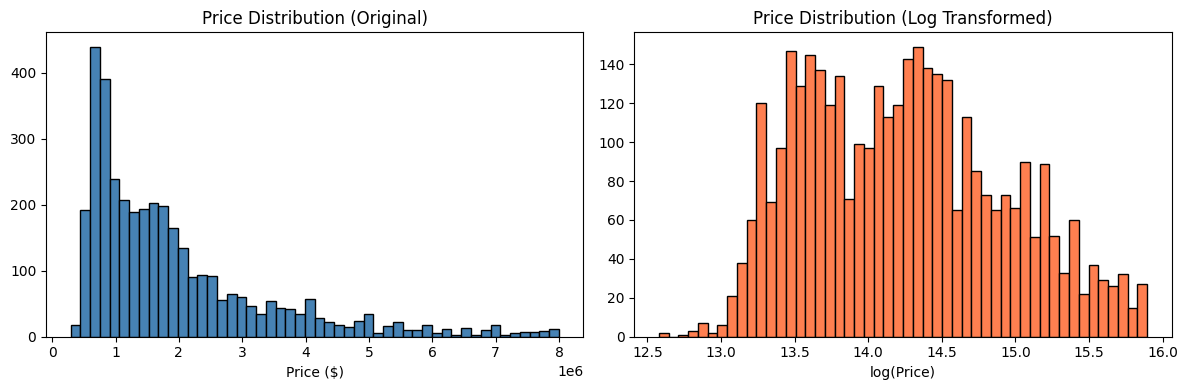

✅ Chart saved!


In [9]:
import numpy as np

# Log-transform price (helps with right-skewed distribution)
df_clean['log_price'] = np.log1p(df_clean['Price'])

print(f"✅ Log price column added")
print(f"Original price mean:  ${df_clean['Price'].mean():,.0f}")
print(f"Log price mean:       {df_clean['log_price'].mean():.4f}")

# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['Price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution (Original)')
axes[0].set_xlabel('Price ($)')

axes[1].hist(df_clean['log_price'], bins=50, color='coral', edgecolor='black')
axes[1].set_title('Price Distribution (Log Transformed)')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.savefig('../outputs/figures/price_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved!")

<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">💾 Step 5 — Save Cleaned File</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Save to data/processed/ for use in spatial join notebook</p>
</div>

In [11]:
df_clean.to_csv('../data/processed/housing_data_cleaned.csv', index=False)

print(f"✅ Saved to data/processed/housing_data_cleaned.csv")
print(f"📊 Shape: {df_clean.shape}")
print(f"💰 Price range: ${df_clean['Price'].min():,.0f} - ${df_clean['Price'].max():,.0f}")
print(f"📊 Median price: ${df_clean['Price'].median():,.0f}")
print(f"📋 Columns: {df_clean.columns.tolist()}")

✅ Saved to data/processed/housing_data_cleaned.csv
📊 Shape: (3665, 15)
💰 Price range: $289,900 - $7,998,000
📊 Median price: $1,499,000
📋 Columns: ['Price', 'Bedrooms', 'Bathrooms', 'Square Footage', 'Latitude', 'Longitude', 'Acreage', 'Garage', 'Parking', 'Fireplace', 'Waterfront', 'Pool', 'Garden', 'Balcony', 'log_price']


<div style="background-color:#1a1a2e; padding:20px; border-radius:10px;">
<h3 style="color:#00d4ff;">📋 Summary — Data Cleaning</h3>
<ul style="color:#a8a8b3; line-height:2;">
<li>✓ Loaded Vancouver properties from Kaggle Canada Housing dataset</li>
<li>✓ Removed price outliers (kept $200K – $8M range)</li>
<li>✓ Removed properties with 0 bedrooms or bathrooms</li>
<li>✓ Dropped rows with missing Square Footage, Latitude, or Longitude</li>
<li>✓ Selected 14 modeling-relevant features</li>
<li>✓ Saved clean file → data/processed/housing_data_cleaned.csv</li>
</ul>
<h3 style="color:#00d4ff; margin-top:15px;">➡️ Next Step</h3>
<p style="color:#a8a8b3;">Run 02b_spatial_join.ipynb to add neighbourhood column using GeoJSON boundaries.</p>
</div>